Setup done ✅
          Model  Accuracy  Precision    Recall        F1
0      Logistic    0.6505   0.034682  0.436364  0.064257
1  DecisionTree    0.9545   0.108696  0.090909  0.099010
2           KNN    0.9725   0.000000  0.000000  0.000000


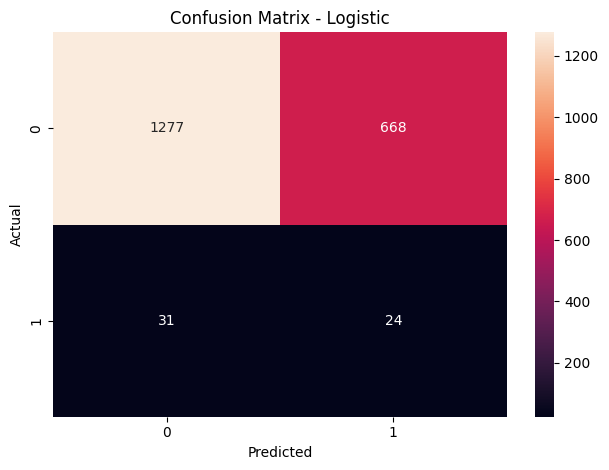

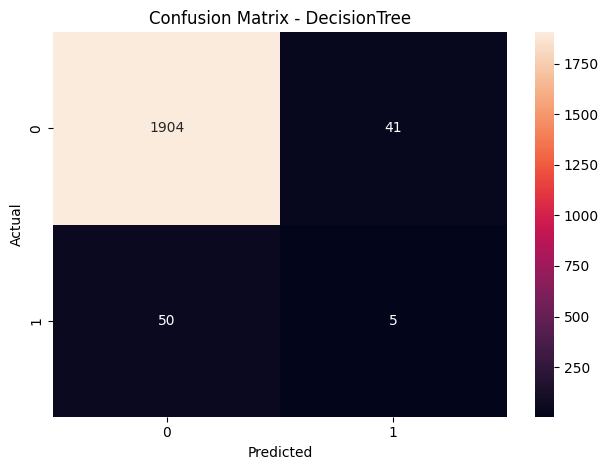

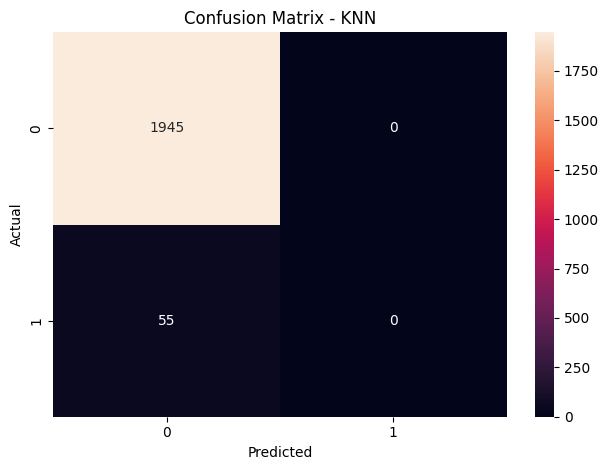

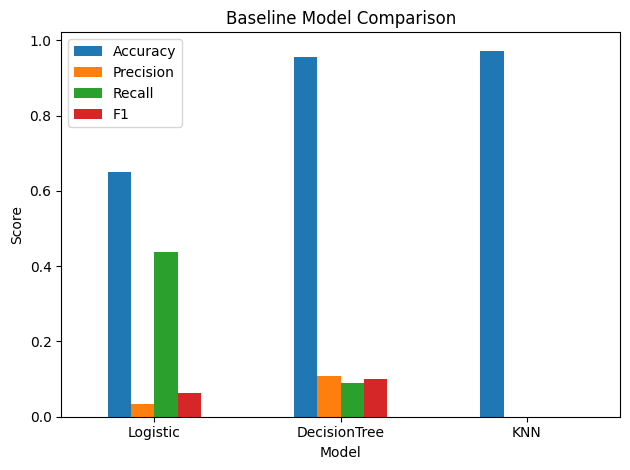

In [2]:
# SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# LOAD DATASET

df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')

df = df.dropna()

# DEFINE X and y

y = df['mortality']
X = df.drop(columns=['mortality'])

# COLUMN TYPES

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# PREPROCESSOR

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Setup done ✅")

# RQ1 MODELS

models = {
    'Logistic': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    
    'DecisionTree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(class_weight='balanced'))
    ]),
    
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier())
    ])
}

# TRAIN + EVALUATE

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'rq1_cm_{name}.pdf')

    # Metrics (clean version)
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ])


# SAVE RESULTS 

results_df = pd.DataFrame(results, columns=[
    'Model','Accuracy','Precision','Recall','F1'
])

results_df.to_csv('rq1_table.csv', index=False)

print(results_df)


# COMPARISON FIGURE 

results_df.set_index('Model')[['Accuracy','Precision','Recall','F1']].plot(kind='bar')
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rq1_bar_chart.pdf")
plt.show()